In [2]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

In [3]:
df=pd.read_csv(r"C:\Users\CHAIT\OneDrive\Desktop\TE\Machine Learning\Dataset\random_forest_regression_dataset.csv")
df.head()

,HouseSize_sqft,Bedrooms,Bathrooms,Age_Years,Distance_City_km,Parking,NeighborhoodScore,HousePrice
0,3219,3,2,23,9.0,0,2.3,16908473
1,3371,5,4,18,13.2,0,1.8,18714962
2,2669,4,3,17,6.8,2,7.3,16035898
3,1502,2,2,25,26.2,0,7.3,8412778
4,1738,1,1,30,23.1,0,1.8,8179914


In [4]:
x=df.iloc[:,:-1]
y=df.iloc[:,-1]

In [5]:
from sklearn.model_selection import train_test_split

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
x_train.size
y_train.size

160

In [13]:
r=RandomForestRegressor(n_estimators=100,random_state=42)

In [14]:
r.fit(x_train,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
y_pred=r.predict(x_test)

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 440909.76775
MSE : 278984518034.94763
RMSE : 528189.8503710078
R2 Score : 0.9909278262368685


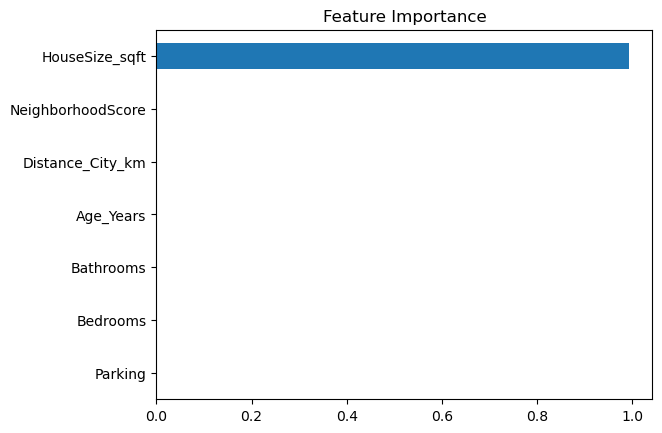

In [19]:
import matplotlib.pyplot as plt
importance = r.feature_importances_

feature = pd.Series(importance, index=x.columns)

feature.sort_values().plot(kind="barh")

plt.title("Feature Importance")

plt.show()